In [1]:
import pandas as pd
transaction_file=pd.read_csv('data/raw/train_transaction.csv')
identity_file=pd.read_csv('data/raw/train_identity.csv')

In [2]:
print("Loading transaction data...")
print("\n========== DATASET SHAPE ==========")
print(transaction_file.shape)
print("\n========== FIRST 5 ROWS ==========")
print(transaction_file.head())
print("\n========== COLUMN TYPES ==========")
print(transaction_file.dtypes.value_counts())
print("\n========== TARGET DISTRIBUTION ==========")
print(transaction_file["isFraud"].value_counts())
print("\n========== TARGET PERCENTAGE ==========")
print(
    transaction_file["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(4)
)
missing = (
    transaction_file.isnull()
    .sum()
    .sort_values(ascending=False)
)
missing_percent = (
    transaction_file.isnull()
    .mean()
    .mul(100)
    .round(2)
)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})
print(missing_df.head(30))
print("\n========== NUMERICAL SUMMARY ==========")
print(transaction_file.describe().T.head(20))
print("\n========== UNIQUE VALUES ==========")
for column in ["ProductCD", "card4", "card6"]:
    if column in transaction_file.columns:
        print(f"\n{column}:")
        print(transaction_file[column].value_counts(dropna=False).head(20))

Loading transaction data...

========== DATASET SHAPE ==========
(590540, 394)

========== FIRST 5 ROWS ==========
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  .

In [3]:
print("\n========== ALL COLUMNS ==========")

for i, column in enumerate(transaction_file.columns, start=1):
    print(f"{i:3}. {column}")


========== ALL COLUMNS ==========
  1. TransactionID
  2. isFraud
  3. TransactionDT
  4. TransactionAmt
  5. ProductCD
  6. card1
  7. card2
  8. card3
  9. card4
 10. card5
 11. card6
 12. addr1
 13. addr2
 14. dist1
 15. dist2
 16. P_emaildomain
 17. R_emaildomain
 18. C1
 19. C2
 20. C3
 21. C4
 22. C5
 23. C6
 24. C7
 25. C8
 26. C9
 27. C10
 28. C11
 29. C12
 30. C13
 31. C14
 32. D1
 33. D2
 34. D3
 35. D4
 36. D5
 37. D6
 38. D7
 39. D8
 40. D9
 41. D10
 42. D11
 43. D12
 44. D13
 45. D14
 46. D15
 47. M1
 48. M2
 49. M3
 50. M4
 51. M5
 52. M6
 53. M7
 54. M8
 55. M9
 56. V1
 57. V2
 58. V3
 59. V4
 60. V5
 61. V6
 62. V7
 63. V8
 64. V9
 65. V10
 66. V11
 67. V12
 68. V13
 69. V14
 70. V15
 71. V16
 72. V17
 73. V18
 74. V19
 75. V20
 76. V21
 77. V22
 78. V23
 79. V24
 80. V25
 81. V26
 82. V27
 83. V28
 84. V29
 85. V30
 86. V31
 87. V32
 88. V33
 89. V34
 90. V35
 91. V36
 92. V37
 93. V38
 94. V39
 95. V40
 96. V41
 97. V42
 98. V43
 99. V44
100. V45
101. V46
102. V47
10

In [6]:
transaction_file['TransactionDT'].head()

0    86400
1    86401
2    86469
3    86499
4    86506
Name: TransactionDT, dtype: int64

In [7]:
print("\n========== TIME RANGE ==========")

print("Minimum TransactionDT:")
print(transaction_file["TransactionDT"].min())

print("Maximum TransactionDT:")
print(transaction_file["TransactionDT"].max())

print("\n========== FRAUD RATE OVER TIME ==========")

transaction_file["time_bin"] = pd.qcut(
    transaction_file["TransactionDT"],
    q=10,
    duplicates="drop"
)

fraud_by_time = transaction_file.groupby(
    "time_bin",
    observed=True
)["isFraud"].agg(
    ["count", "sum", "mean"]
)

fraud_by_time["fraud_percent"] = (
    fraud_by_time["mean"] * 100
)

print(fraud_by_time)


========== TIME RANGE ==========
Minimum TransactionDT:
86400
Maximum TransactionDT:
15811131

========== FRAUD RATE OVER TIME ==========
                          count   sum      mean  fraud_percent
time_bin                                                      
(86399.999, 1361004.4]    59054  1631  0.027619       2.761879
(1361004.4, 2310159.6]    59054  1195  0.020236       2.023572
(2310159.6, 3864163.9]    59054  2200  0.037254       3.725404
(3864163.9, 5592303.6]    59054  2532  0.042876       4.287601
(5592303.6, 7306527.5]    59054  2336  0.039557       3.955702
(7306527.5, 8745782.4]    59054  2094  0.035459       3.545907
(8745782.4, 10437998.1]   59054  2550  0.043181       4.318082
(10437998.1, 12192853.6]  59054  2061  0.034900       3.490026
(12192853.6, 13990907.7]  59054  1851  0.031344       3.134419
(13990907.7, 15811131.0]  59054  2213  0.037474       3.747418


<Axes: xlabel='isFraud'>

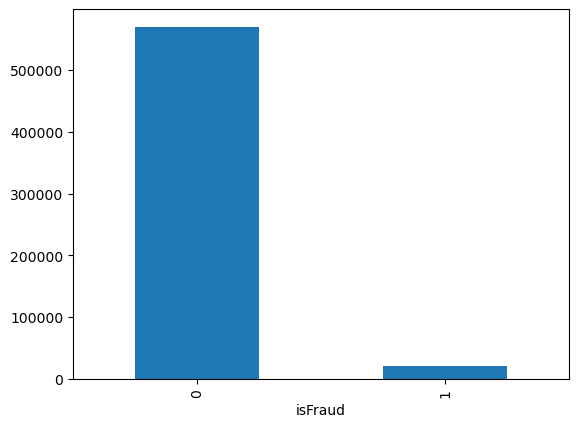

In [8]:
transaction_file['isFraud'].value_counts().plot(kind='bar')